## Nome: Caio Semblano Silva
## Matrícula: 621

---

# Atividade 10 - Integradora 

Uma equipe de engenharia está analisando o sistema de resfriamento de um reator químico acoplado a uma malha de tubulação.

O trabalho tem **duas etapas conectadas**:

1. **Etapa 1 — Sistemas Lineares:** a temperatura em regime permanente de 3 nós de junção da malha de tubulação é modelada por um sistema linear $A\cdot x = b$, resolvido pelo **Método de Gauss-Seidel**.
2. **Etapa 2 — Ajuste Não Linear:** a evolução da temperatura de um desses nós **ao longo do tempo**, durante o resfriamento transiente, segue um comportamento não linear (exponencial amortecido com componente oscilatória), ajustado pelo **Método de Gauss-Newton**.

**A conexão entre as duas etapas:** o método de Gauss-Newton, usado na Etapa 2, precisa resolver um sistema linear a cada iteração:

$$ (J^T J)\,\Delta = -J^T r $$

Nas atividades anteriores esse sistema era resolvido com `np.linalg.solve` (método direto). Nesta atividade, você vai **resolver esse sistema usando a sua própria implementação do Gauss-Seidel** (Etapa 1), integrando os dois métodos estudados.

---

## Personalização por Matrícula

**Todo o sistema linear da Etapa 1 e a estimativa inicial da Etapa 2 dependem da sua matrícula**.

Extraia três dígitos da sua matrícula da seguinte forma:

$$d_1 = matrícula \%  5 \qquad d_2 = \left\lfloor \dfrac{matrícula}{10} \right\rfloor \% 5 \qquad d_3 = \left\lfloor \dfrac{matrícula}{100} \right\rfloor \% 5$$

Esses valores serão usados para:
- Ajustar o vetor $b$ do sistema linear da Etapa 1.
- Ajustar a estimativa inicial $p_0$ do ajuste não linear da Etapa 2.

**Implemente a célula abaixo com a sua matrícula.** Todo o restante da atividade depende deste valor.

**Importante: Use/adapte as funções de atividades anteriores. Implementações diferentes serão desconsideradas.**

In [1]:
# TODO: substitua pelo valor da sua matrícula
matricula = 621  # <-- coloque aqui sua matrícula

d1 = matricula % 5
d2 = (matricula // 10) % 5
d3 = (matricula // 100) % 5

print(f"Matrícula: {matricula}")
print(f"d1 = {d1}  |  d2 = {d2}  |  d3 = {d3}")

Matrícula: 621
d1 = 1  |  d2 = 2  |  d3 = 1


---

# Etapa 1 — Sistema Linear e Método de Gauss-Seidel

A malha de tubulação possui 3 nós de interesse ($T_1$, $T_2$, $T_3$). O balanço térmico resultou no sistema:

$$10T_1 - T_2 + 2T_3 = 6 + d_1$$
$$-T_1 + 11T_2 - T_3 = 25 + d_2$$
$$2T_1 - T_2 + 10T_3 = -11 + d_3$$

onde $d_1$, $d_2$, $d_3$ são os valores calculados a partir da sua matrícula.

In [2]:
from IPython.display import display

# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit 

### Parte 1.1 — Montagem do Sistema Personalizado

Monte a matriz `A` e o vetor `b` usando `d1`, `d2`, `d3` calculados a partir da sua matrícula. Exiba a tabela de coeficientes.

In [3]:
# funções da AT4

def eh_diagonalmente_dominante(A):
    n = A.shape[0]
    dominante = True
    for i in range(n):
        diagonal = np.abs(A[i, i])
        soma_resto = np.sum(np.abs(A[i, :])) - diagonal
        print(f"Linha {i+1}: |a_{{{i+1}{i+1}}}| = {diagonal:.2f}  |  soma dos demais = {soma_resto:.2f}  ->",
            "OK" if diagonal > soma_resto else "NÃO satisfaz")
        if diagonal <= soma_resto:
            dominante = False
    return dominante

def gauss_seidel(A, b, x0=None, tol=1e-4, max_iter=50, mostrar=True):
    n = len(b)
    x = np.zeros(n) if x0 is None else x0.copy()
    historico = [x.copy()]

    for k in range(1, max_iter + 1):
        x_antigo = x.copy()
        for i in range(n):
            soma1 = np.dot(A[i, :i], x[:i])            # valores já atualizados
            soma2 = np.dot(A[i, i+1:], x_antigo[i+1:])  # valores da iteração anterior
            x[i] = (b[i] - soma1 - soma2) / A[i, i]

        historico.append(x.copy())
        erro = np.max(np.abs(x - x_antigo))

        if erro < tol:
            if mostrar:
                print(f"Convergiu na iteração {k} (erro = {erro:.2e})")
            break
    else:
        if mostrar:
            print(f"Número máximo de iterações ({max_iter}) atingido sem convergir para a tolerância definida.")

    return x, np.array(historico)

def plot_convergencia(historico, titulo="Convergência do Método de Gauss-Seidel"):
    historico = np.array(historico)
    erros = np.max(np.abs(np.diff(historico, axis=0)), axis=1)
    iteracoes = np.arange(1, len(erros) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(iteracoes, erros, marker="o")
    plt.yscale("log")
    plt.xlabel("Iteração")
    plt.ylabel("Erro máximo entre iterações (escala log)")
    plt.title(titulo)
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.show()


# sistema personalizado com d1, d2, d3
A = np.array([
    [10, -1,  2],
    [-1, 11, -1],
    [ 2, -1, 10]
], dtype=float)

b = np.array([6 + d1, 25 + d2, -11 + d3], dtype=float)

tabela = pd.DataFrame(A, columns=["T1", "T2", "T3"], index=["Eq. 1", "Eq. 2", "Eq. 3"])
tabela["b"] = b
display(tabela)

,T1,T2,T3,b
Eq. 1,10.0,-1.0,2.0,7.0
Eq. 2,-1.0,11.0,-1.0,27.0
Eq. 3,2.0,-1.0,10.0,-10.0


### Parte 1.2 — Verificação da Convergência (Dominância Diagonal)

Verifique se a matriz `A` do seu sistema personalizado é estritamente diagonalmente dominante, usando a função `eh_diagonalmente_dominante`.

In [4]:
dominante = eh_diagonalmente_dominante(A)
print("Matriz estritamente diagonalmente dominante?", dominante)

Linha 1: |a_{11}| = 10.00  |  soma dos demais = 3.00  -> OK
Linha 2: |a_{22}| = 11.00  |  soma dos demais = 2.00  -> OK
Linha 3: |a_{33}| = 10.00  |  soma dos demais = 3.00  -> OK
Matriz estritamente diagonalmente dominante? True


**Formulário — Critério de Dominância Diagonal**

$$|a_{ii}| > \sum_{\substack{j=1 \\ j \neq i}}^{n} |a_{ij}|$$

### Parte 1.3 — Resolução pelo Método de Gauss-Seidel

Resolva o sistema com:
- Estimativa inicial: $x^{(0)} = [0, 0, 0]$
- Tolerância: $\varepsilon = 10^{-4}$
- Número máximo de iterações: $50$

In [5]:
x0 = np.zeros(3)
T_final, historico_T = gauss_seidel(A, b, x0=x0, tol=1e-4, max_iter=50)
print("T1, T2, T3 =", T_final)

Convergiu na iteração 5 (erro = 2.52e-05)
T1, T2, T3 = [ 1.14327068  2.46923046 -0.98173109]


**Formulário — Método de Gauss-Seidel**

$$x_i^{(k+1)} = \frac{1}{a_{ii}}\left(b_i - \sum_{j < i} a_{ij}\,x_j^{(k+1)} - \sum_{j > i} a_{ij}\,x_j^{(k)}\right)$$

**Critério de Parada:**

$$\max_i \left| x_i^{(k+1)} - x_i^{(k)} \right| < \varepsilon$$

### Parte 1.4 — Tabela de Iterações

Armazene os valores de $T_1$, $T_2$, $T_3$ obtidos em cada iteração em um DataFrame.

In [6]:
tabela_iteracoes = pd.DataFrame(historico_T, columns=["T1", "T2", "T3"])
tabela_iteracoes.index.name = "Iteração"
display(tabela_iteracoes)

,T1,T2,T3
Iteração,,,
0,0.000000,0.000000,0.000000
1,0.700000,2.518182,-0.888182
2,1.129455,2.476479,-0.978243
3,1.143297,2.469550,-0.981704
4,1.143296,2.469236,-0.981736
5,1.143271,2.469230,-0.981731


### Parte 1.5 — Comparação com a Solução Exata

Resolva o mesmo sistema (personalizado) com `np.linalg.solve` e compare com o resultado do Gauss-Seidel (Erro Absoluto e Erro Percentual).

In [7]:
T_exato = np.linalg.solve(A, b)

erro_absoluto = np.abs(T_exato - T_final)
erro_percentual = (erro_absoluto / np.abs(T_exato)) * 100

df_comparacao = pd.DataFrame({
    "Solução Exata (np.linalg)": T_exato,
    "Sol. Aprox (Gauss-Seidel)": T_final,
    "Erro Absoluto": erro_absoluto,
    "Erro Percentual (%)": erro_percentual,
}, index=["T1", "T2", "T3"])

display(df_comparacao)

,Solução Exata (np.linalg),Sol. Aprox (Gauss-Seidel),Erro Absoluto,Erro Percentual (%)
T1,1.143269,1.143271,1.452809e-06,0.000127
T2,2.469231,2.469230,3.086580e-07,0.000013
T3,-0.981731,-0.981731,3.214276e-07,0.000033


### Parte 1.6 — Gráfico de Convergência

Use `plot_convergencia` para visualizar a evolução do erro entre iterações.

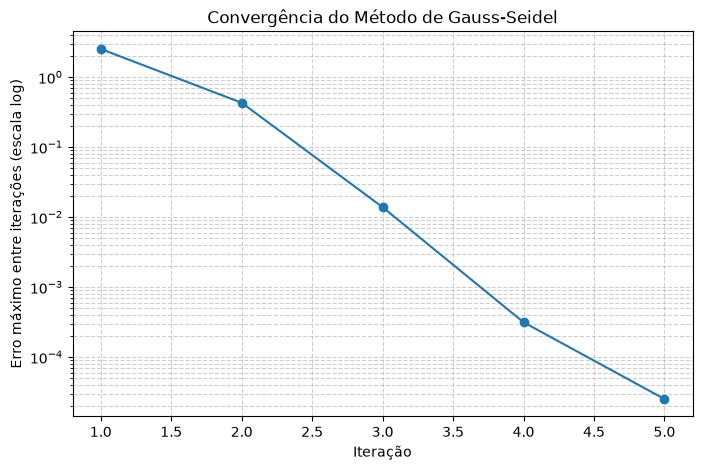

In [8]:
plot_convergencia(historico_T)

---

# Etapa 2 — Ajuste Não Linear (integrando o Gauss-Seidel)

Um dos nós da malha ($T_1$) foi monitorado ao longo do tempo durante um transiente de resfriamento. O comportamento não segue um polinômio simples, exigindo um modelo não linear ("função cabeluda"):

$$T(t) = T_{amb} + A \cdot e^{-a \cdot t} + B \cdot e^{-b \cdot t} \cdot \cos(w \cdot t)$$

Os dados coletados pelo sistema SCADA estão na tabela abaixo. **Antes de usar os dados, aplique a personalização pela matrícula**: some $\left(\dfrac{d_1 - 2}{2}\right)$ a todos os valores de temperatura medidos (pequeno deslocamento vertical, específico da sua matrícula).

In [9]:
ts = np.array([0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 7.0, 9.0, 12.0])
ys_base = np.array([820.0, 695.5, 580.2, 415.0, 310.8, 240.3, 192.1, 135.4, 102.7, 75.0])

# Personalização pela matrícula: pequeno deslocamento vertical
deslocamento = (d1 - 2) / 2
ys = ys_base + deslocamento

tabela_dados = pd.DataFrame({"t (min)": ts, "T medida (°C)": ys})
display(tabela_dados)

,t (min),T medida (°C)
0,0.0,819.5
1,0.5,695.0
2,1.0,579.7
3,2.0,414.5
4,3.0,310.3
5,4.0,239.8
6,5.0,191.6
7,7.0,134.9
8,9.0,102.2
9,12.0,74.5


In [10]:
# Modelo: Decaimento Exponencial Amortecido com Termo Senoidal Amortecido (fornecido)
def modelo_nao_linear(t, T_amb, A, a, B, b, w):
    return T_amb + A * np.exp(-a * t) + B * np.exp(-b * t) * np.cos(w * t)

### A integração: resolvendo o sistema normal com Gauss-Seidel

A função `ajustar_modelo` abaixo implementa o método de Gauss-Newton. A cada iteração, ela precisa resolver o sistema linear:

$$(J^T J)\,\Delta = -J^T r$$

O parâmetro `metodo_solver` controla **como** esse sistema é resolvido:
- `'direto'` → usa `np.linalg.solve` (como nas atividades anteriores).
- `'gauss_seidel'` → usa a **sua função `gauss_seidel`** implementada na Etapa 1.

Note que $(J^TJ)$ é sempre simétrica, mas **não necessariamente diagonalmente dominante** — isso é algo que você vai investigar na Parte Teórica.

In [11]:
def ajustar_modelo(t, y, params0, metodo_solver='direto', max_iter=200, tol=1e-8):
    """
    Ajusta o modelo não linear aos dados (t, y) pelo método de Gauss-Newton,
    partindo da estimativa inicial params0.

    Parâmetros:
    -----------
    t, y : array-like
        Dados medidos.
    params0 : array-like
        Estimativa inicial dos parâmetros (T_amb, A, a, B, b, w).
    metodo_solver : str
        'direto'        -> resolve (J^T J) delta = -J^T r com np.linalg.solve
        'gauss_seidel'  -> resolve (J^T J) delta = -J^T r com a função gauss_seidel (Etapa 1)
    max_iter, tol : parâmetros de parada do Gauss-Newton.

    Retorna:
    --------
    popt : array
        Parâmetros otimizados (T_amb, A, a, B, b, w).
    """
    def residuo(params):
        return modelo_nao_linear(t, *params) - y

    def jacobiano_numerico(params, eps=1e-6):
        n = len(params)
        r0 = residuo(params)
        J = np.zeros((len(t), n))
        for j in range(n):
            p_perturbado = params.copy()
            p_perturbado[j] += eps
            J[:, j] = (residuo(p_perturbado) - r0) / eps
        return J, r0

    params = np.array(params0, dtype=float)
    for _ in range(max_iter):
        J, r = jacobiano_numerico(params)
        JTJ = J.T @ J
        JTr = J.T @ r

        if metodo_solver == 'direto':
            delta = np.linalg.solve(JTJ, -JTr)
        elif metodo_solver == 'gauss_seidel':
            # Gauss-Seidel da etapa 1
            delta, _ = gauss_seidel(JTJ, -JTr, tol=1e-8, max_iter=500, mostrar=False)
        else:
            raise ValueError("metodo_solver deve ser 'direto' ou 'gauss_seidel'")

        alpha = 1.0
        erro_atual = np.sum(r**2)
        while True:
            novo_params = params + alpha * delta
            novo_erro = np.sum(residuo(novo_params)**2)
            if novo_erro < erro_atual or alpha < 1e-8:
                break
            alpha /= 2

        params = novo_params
        if np.linalg.norm(alpha * delta) < tol:
            break

    return params  # Saídas: T_amb, A, a, B, b, w

### Parte 2.1 — Completar a Integração

Complete o trecho `TODO` da função `ajustar_modelo` acima, chamando a sua função `gauss_seidel` para resolver o sistema normal quando `metodo_solver='gauss_seidel'`.

In [12]:
# feito dentro de ajustar_modelo

### Parte 2.2 — Estimativa Inicial Personalizada e Ajuste do Modelo

Use a estimativa inicial $p_0 = [25 + d_3,\ 600,\ 0.2,\ 200,\ 0.1,\ 1.5]$ e ajuste o modelo aos dados **usando `metodo_solver='gauss_seidel'`**.

Em seguida, estime a temperatura nos instantes $t = 1.5$ min, $t = 6.0$ min e $t = 10.0$ min (arredonde para duas casas decimais).

In [13]:
p0 = np.array([25 + d3, 600.0, 0.2, 200.0, 0.1, 1.5])
print("Chute inicial p0:", p0)

params_gs = ajustar_modelo(ts, ys, p0, metodo_solver="gauss_seidel")

nomes = ["T_amb", "A", "a", "B", "b", "w"]
print("\nParâmetros ajustados (Gauss-Seidel):")
for nome, valor in zip(nomes, params_gs):
    print(f"  {nome:>5} = {valor:.6f}")

instantes = [1.5, 6.0, 10.0]
print("\nTemperaturas estimadas:")
for t in instantes:
    T = modelo_nao_linear(t, *params_gs)
    print(f"  t = {t:4.1f} min  ->  {T:.2f} °C")

Chute inicial p0: [2.6e+01 6.0e+02 2.0e-01 2.0e+02 1.0e-01 1.5e+00]



Parâmetros ajustados (Gauss-Seidel):
  T_amb = 56.200561
      A = 613.835514
      a = 0.291132
      B = 150.548676
      b = 0.631926
      w = 0.585315

Temperaturas estimadas:
  t =  1.5 min  ->  490.11 °C
  t =  6.0 min  ->  160.05 °C
  t = 10.0 min  ->  89.84 °C


### Parte 2.3 — Comparação: Gauss-Seidel vs. Método Direto

Rode `ajustar_modelo` também com `metodo_solver='direto'` e compare os parâmetros otimizados e as estimativas de temperatura obtidas pelos dois métodos. Eles deveriam ser praticamente iguais — comente o porquê.

In [14]:
params_dir = ajustar_modelo(ts, ys, p0, metodo_solver="direto")

T_gs = [modelo_nao_linear(t, *params_gs) for t in instantes]
T_dir = [modelo_nao_linear(t, *params_dir) for t in instantes]

df_params = pd.DataFrame({
    "Gauss-Seidel": params_gs,
    "Direto (np.linalg.solve)": params_dir,
    "Diferença absoluta": np.abs(params_gs - params_dir),
}, index=nomes)

df_temp = pd.DataFrame({
    "t (min)": instantes,
    "T Gauss-Seidel (°C)": np.round(T_gs, 2),
    "T direto (°C)": np.round(T_dir, 2),
})

display(df_params)
display(df_temp)

# J^T J no chute inicial
def residuo_no_chute(params):
    return modelo_nao_linear(ts, *params) - ys

eps = 1e-6
r0 = residuo_no_chute(p0)
J0 = np.zeros((len(ts), len(p0)))
for j in range(len(p0)):
    p_pert = p0.copy()
    p_pert[j] += eps
    J0[:, j] = (residuo_no_chute(p_pert) - r0) / eps

JTJ0 = J0.T @ J0
print("\nDominância diagonal de J^T J no chute inicial:")
print("É estritamente diagonalmente dominante?", eh_diagonalmente_dominante(JTJ0))
print(f"Número de condição de J^T J ≈ {np.linalg.cond(JTJ0):.3e}")

,Gauss-Seidel,Direto (np.linalg.solve),Diferença absoluta
T_amb,56.200561,56.200558,3.352440e-06
A,613.835514,613.835481,3.297079e-05
a,0.291132,0.291132,1.653278e-08
B,150.548676,150.548713,3.648468e-05
b,0.631926,0.631926,7.860902e-09
w,0.585315,0.585315,8.313152e-08


,t (min),T Gauss-Seidel (°C),T direto (°C)
0,1.5,490.11,490.11
1,6.0,160.05,160.05
2,10.0,89.84,89.84



Dominância diagonal de J^T J no chute inicial:
Linha 1: |a_{11}| = 10.00  |  soma dos demais = 8587.33  -> NÃO satisfaz
Linha 2: |a_{22}| = 3.67  |  soma dos demais = 3273.87  -> NÃO satisfaz
Linha 3: |a_{33}| = 6614889.73  |  soma dos demais = 1110352.38  -> OK
Linha 4: |a_{44}| = 2.78  |  soma dos demais = 1714.31  -> NÃO satisfaz
Linha 5: |a_{55}| = 954904.73  |  soma dos demais = 1093392.80  -> NÃO satisfaz
Linha 6: |a_{66}| = 1588594.38  |  soma dos demais = 557213.84  -> OK
É estritamente diagonalmente dominante? False
Número de condição de J^T J ≈ 5.166e+07


---

---

# Parte de Síntese — Baseada nos Seus Resultados

Esta seção final é dedicada à reflexão teórica e à interpretação crítica do trabalho realizado nas Etapas 1 e 2. 

**Importante:** Não é necessário implementar nenhum código novo. Todas as respostas devem ser fundamentadas exclusivamente nas **tabelas, gráficos, verificações e valores numéricos que você obteve no seu próprio notebook** (personalizados pela sua matrícula).

---
### Pergunta 1 — Comportamento da Convergência e Taxa de Decaimento do Erro (Etapa 1)

Consulte a sua **Tabela de Iterações (Parte 1.4)** e o seu **Gráfico de Convergência (Parte 1.6)** obtidos para o seu sistema personalizado:

1. Quantas iterações o seu método de Gauss-Seidel necessitou para atingir a tolerância $\varepsilon = 10^{-4}$?
2. Mesmo que cada aluno da turma possua valores diferentes de $d_1, d_2, d_3$ (e, portanto, vetores $b$ diferentes com temperaturas finais distintas), o **número de iterações** e a **taxa de decaimento do erro** foram praticamente idênticos para todos. Explique esse fenômeno com base na teoria de convergência do Gauss-Seidel: por que a contração do vetor de erro depende exclusivamente da matriz $A$ e não do vetor de termos independentes $b$?

> **Sua Resposta Teórica (Pergunta 1):**
>
> No meu caso o Gauss-Seidel parou na **iteração 5**, com erro de 2,52×10⁻⁵, já abaixo de 10⁻⁴. Na tabela, a partir da iteração 3 as três temperaturas quase não andam mais: T1 fica em torno de 1,143, T2 em 2,469 e T3 em −0,982. No gráfico (escala log) o erro desce rápido, quase em linha reta, de cerca de 2,5 até a casa de 10⁻⁵.
>
> O número de iterações acaba parecido pra turma inteira porque a matriz A é a mesma pra todo mundo. A matrícula só muda o vetor b. No meu caso ficou b = [7, 27, −10]. O método pode ser escrito como x^(k+1) = G x^(k) + c. A matriz G vem da divisão de A em diagonal, parte de baixo e parte de cima, então ela não depende de b. O b entra só no vetor c. O erro e^(k) = x^(k) − x* obedece e^(k+1) = G e^(k), e o b some dessa conta. A velocidade da queda é o raio espectral de G, ou seja, só de A. Como o chute [0, 0, 0] e a tolerância também são os mesmos, a quantidade de passos fica praticamente igual. Na AT4, com o b original, eu também tinha parado na iteração 5.

---
### Pergunta 2 — Critério de Parada por Passo Sucessivo vs. Erro Real da Solução (Etapa 1)

Na **Parte 1.5**, você comparou a solução numérica obtida pelo seu Gauss-Seidel com a solução exata fornecida por `np.linalg.solve`:

Quais foram as ordens de grandeza dos maiores **Erros Absolutos** e **Erros Percentuais** encontrados para as temperaturas $T_1, T_2, T_3$ na sua Parte 1.5?


> **Sua Resposta Teórica (Pergunta 2):**
>
> O maior erro absoluto foi o de T1, cerca de 1,45×10⁻⁶. T2 e T3 ficaram em torno de 3×10⁻⁷. Em percentual, o maior também foi T1, 0,000127% (ordem de 10⁻⁴ %). T2 deu 0,000013% e T3 deu 0,000033%, os dois na ordem de 10⁻⁵ %.
>
> O critério de parada olha a diferença entre duas iterações seguidas e corta em 10⁻⁴. O erro de verdade, contra o `np.linalg.solve`, ficou bem menor que isso: de 10⁻⁶ a 10⁻⁷ em temperatura. Como a matriz é bem diagonal dominante, quando o passo já está pequeno a solução já encostou na exata.

---
### Pergunta 3 — Análise Comparativa dos Solvers e Interpretação Física dos Resultados

Analise a tabela comparativa entre os métodos direto e iterativo gerada na **Parte 2.3** e a influência da sua matrícula no comportamento físico:

1. **Equivalência Numérica (Parte 2.3):** Ao comparar os 6 parâmetros otimizados ($T_{amb}, A, a, B, b, w$) e as estimativas de temperatura nos instantes $t = 1.5$, $t = 6.0$ e $t = 10.0$ min, os resultados obtidos por `np.linalg.solve` e pela sua função `gauss_seidel` foram equivalentes? Se houve alguma discrepância residual nas últimas casas decimais, a que fator numérico você a atribui?
2. **Sensibilidade Física da Personalização:** O deslocamento vertical $(d_1 - 2)/2$ nas temperaturas medidas e a alteração de $d_3$ no chute inicial provocaram alguma instabilidade na convergência do algoritmo ou o método encontrou o regime térmico de resfriamento de forma robusta?

> **Sua Resposta Teórica (Pergunta 3):**
>
> Sim, ficaram equivalentes. Os seis parâmetros bateram até várias casas. A maior diferença absoluta foi em B, uns 3,6×10⁻⁵, e em A uns 3,3×10⁻⁵. Em a, b e w a diferença ficou na ordem de 10⁻⁸. As temperaturas com duas casas saíram iguais nos dois métodos: **490,11 °C** em 1,5 min, **160,05 °C** em 6 min e **89,84 °C** em 10 min.
>
> O que sobra nas últimas casas vem do sistema de dentro do Gauss-Newton. Montei JᵀJ no chute inicial e ela não é diagonalmente dominante: 4 das 6 linhas não passam no critério, e o número de condição deu cerca de 5×10⁷. O Gauss-Seidel aproxima o Δ pela tolerância do passo, e o `np.linalg.solve` resolve aquele sistema direto. Os parâmetros também têm escalas bem diferentes (T_amb e A são centenas, a e w são frações), então o sistema normal fica mal condicionado e sobra um resíduo pequeno. Na temperatura, arredondando em duas casas, isso some.
>
> A personalização foi pequena. Com d1 = 1 o deslocamento foi (1 − 2)/2 = −0,5 °C em todos os pontos, e d3 = 1 só mudou o chute de T_amb de 25 para 26. O ajuste convergiu nos dois solvers para o mesmo regime: temperatura ambiente perto de 56 °C, a curva saindo de 819,5 °C e caindo até a casa dos 70 °C em 12 min. Não teve instabilidade.